# Lab 5: Regression and Dimensionality Reduction

This exercise repeats the same scenario as Lab 4, but this time we train a regression model, i.e. a model for numeric prediction. We also include a dimensionality-reduction step in the training pipeline. Note that dimensionality reduction can be included in classification pipelines in the same way. 

In this exercise, we use the `fish market` dataset, taken from https://www.kaggle.com/aungpyaeap/fish-market. Each example in this dataset represents a fish. The first column lists the fish species name, and the remaining six columns contain numerical characteristics of the fish. 

In this exercise, we aim to train a regression model for predicting the weight of a fish from its other characteristics. We will evaluate two regression algorithms, `RandomForestRegressor` and `LinearRegression`, to choose the better one for training the final model.

In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import (ColumnTransformer, TransformedTargetRegressor)
from sklearn.preprocessing import (StandardScaler, RobustScaler, OneHotEncoder)
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
    cross_validate
)
from sklearn import set_config
import pickle
import matplotlib.pyplot as plt
%matplotlib inline

# imports necessary for dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE
from sklearn import svm

# regression algorithms
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# metrics for evaluating regression models
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 1. EDA

We start with a brief EDA to check for missing values and outliers.

In [2]:
df = pd.read_csv("./fish.csv")
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [3]:
df.tail()

,Species,Weight,Length1,Length2,Length3,Height,Width
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672
158,Smelt,19.9,13.8,15.0,16.2,2.9322,1.8792


Let's examine values in the categorical column `Species` first.

In [4]:
df['Species'].value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

Now, let's check for missing values and outliers.

In [5]:
df.isna().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

There are no obvious missing values. Let's also examine the basic statistics of the numerical attributes.

In [6]:
df.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


They all look OK, except the minimum value for `Weight` which is 0. It must be a missing value represented by 0. Let's find out how many data rows have `Weight=0`.

In [7]:
df[df.Weight == 0]

,Species,Weight,Length1,Length2,Length3,Height,Width
40,Roach,0.0,19.0,20.5,22.8,6.4752,3.3516


It is just one data row. We will drop it later as it cannot be used for training or test. The model that we will train, though, can be used to predict the weight of this fish.

Next, let's check for outliers in the numerical columns. Based on the table above we can try to plot all numerical columns except `Weight` together.

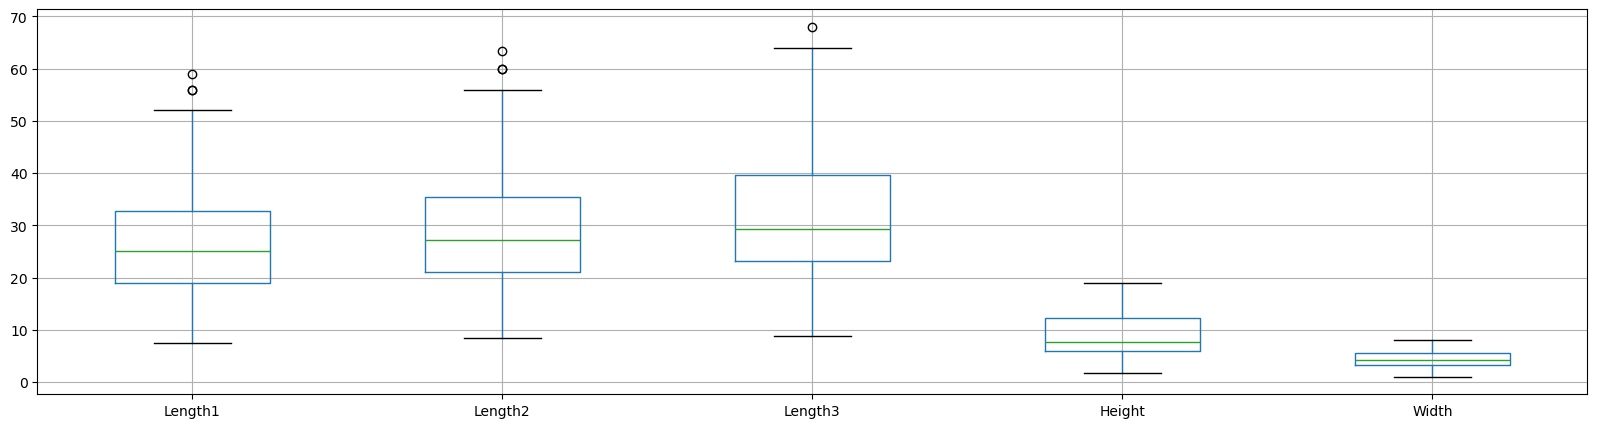

In [8]:
df.drop('Weight', axis=1).boxplot(figsize=(20,5))
plt.show()

There are some outliers in the `length` columns. We will apply RobustScaler to them and StandardScaler to `Height` and `Width`. 

Let’s also examine the histograms of the numerical predictors.

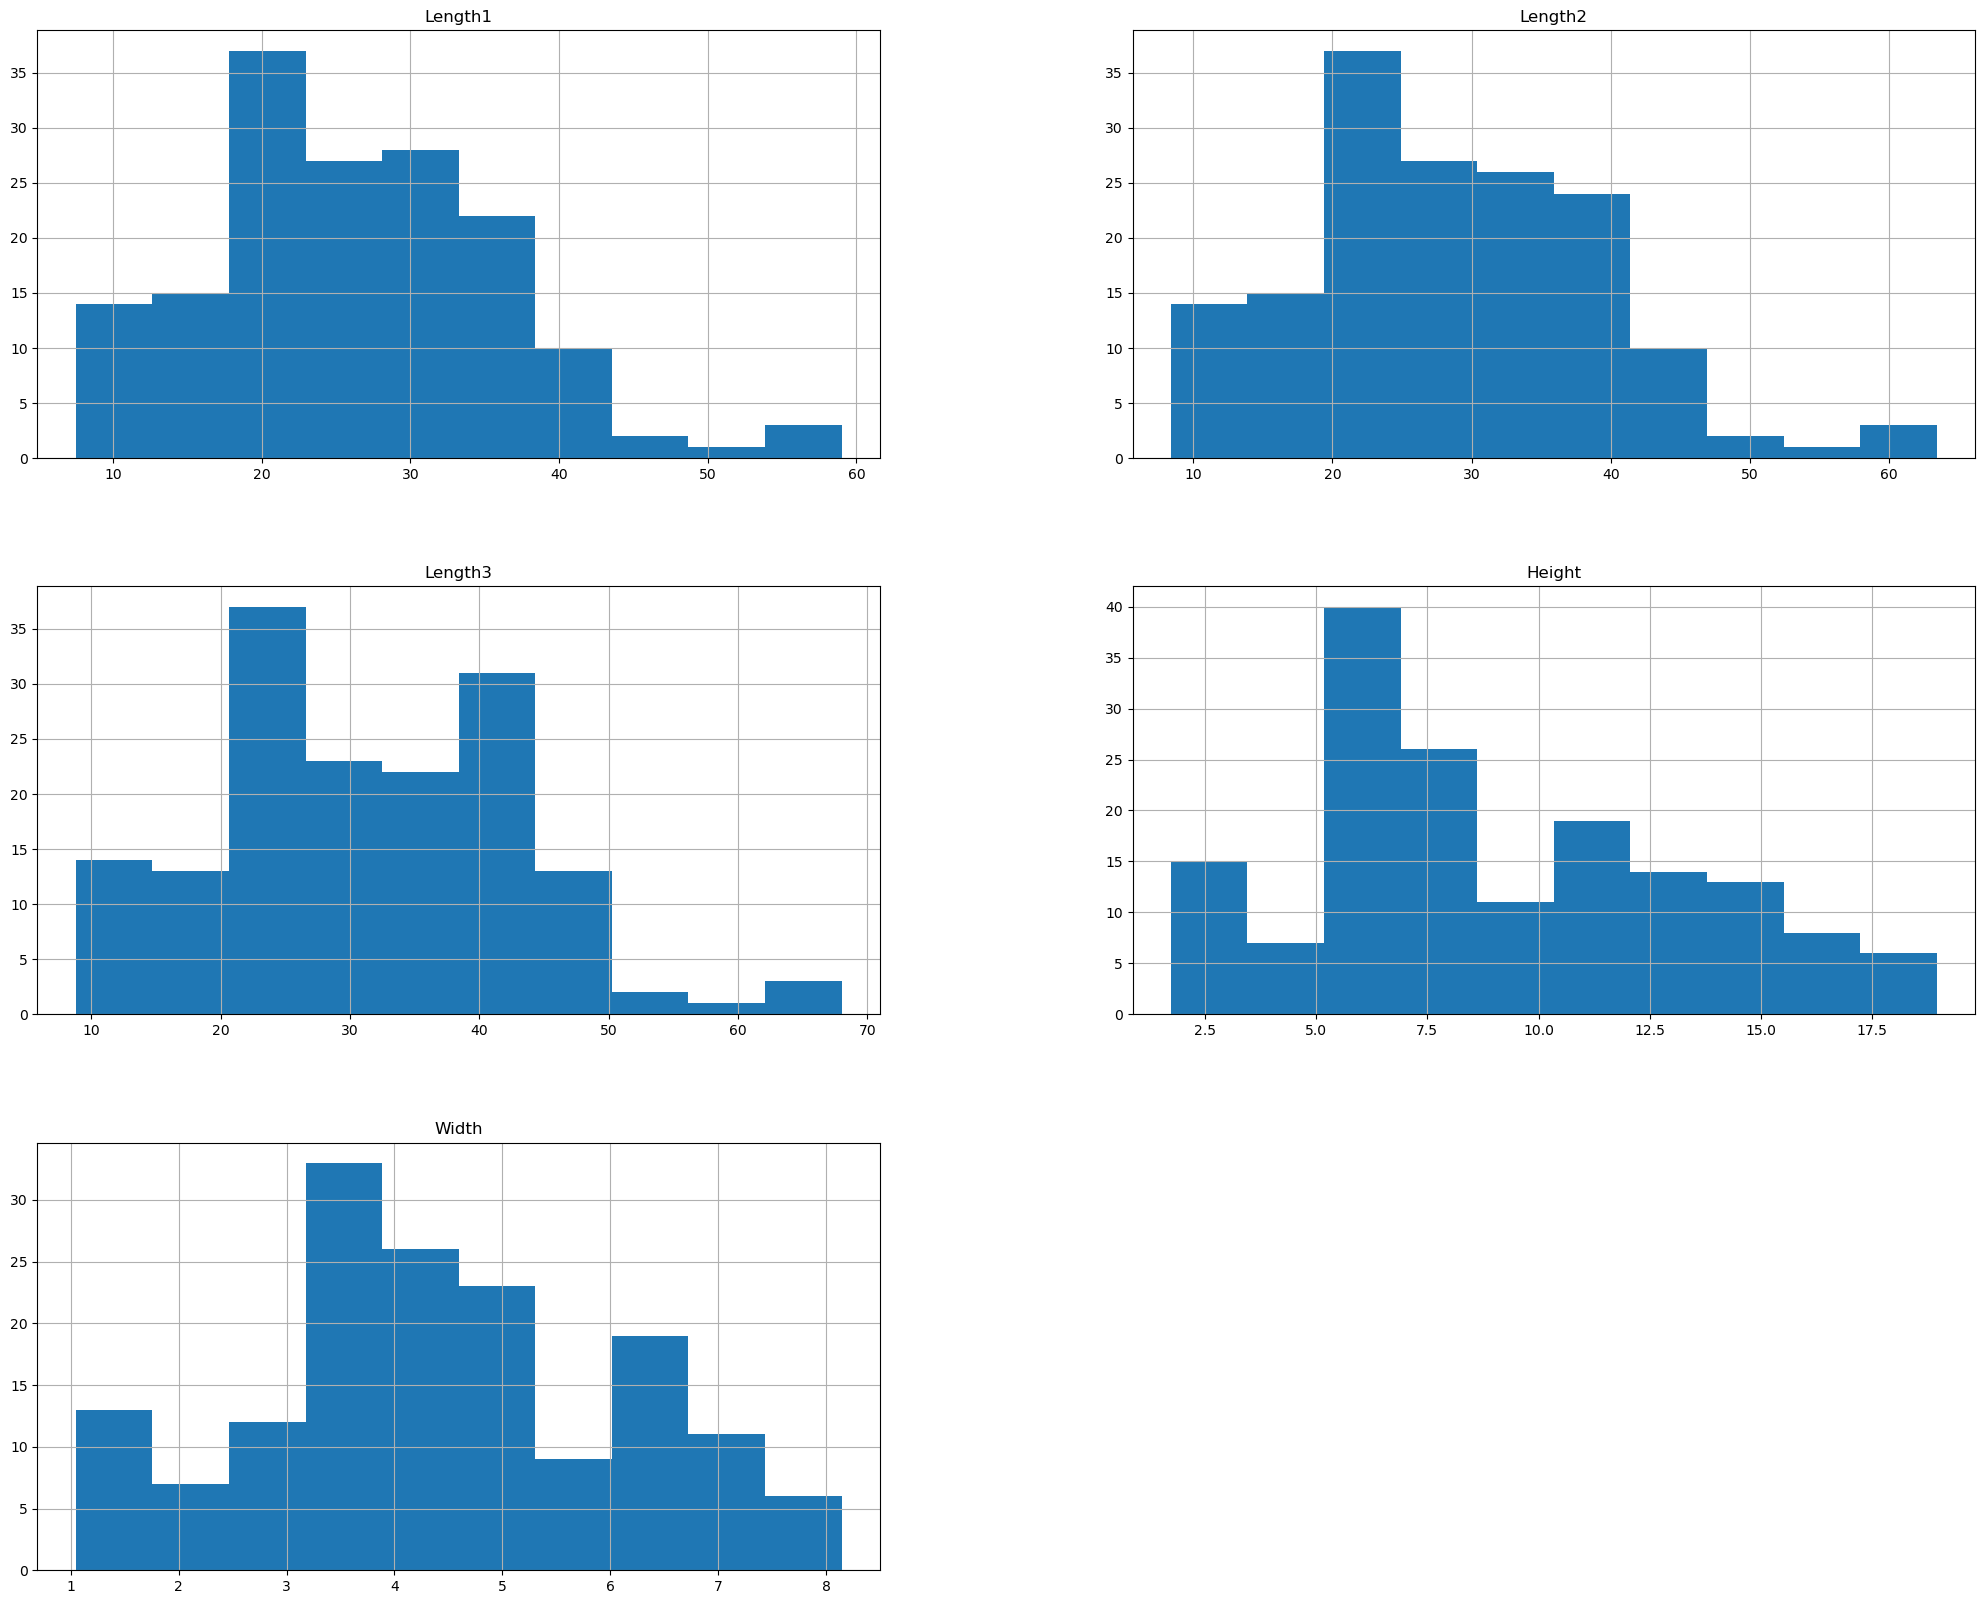

In [9]:
df.drop('Weight', axis=1).hist(bins=10, figsize=(25, 20));

The histograms above do not suggest extreme skewness in the predictors, so we will not apply a logarithmic or cubic-root transformation to them.

Next, let's examine the `Weight` column which is the target of the regression model we are about to train

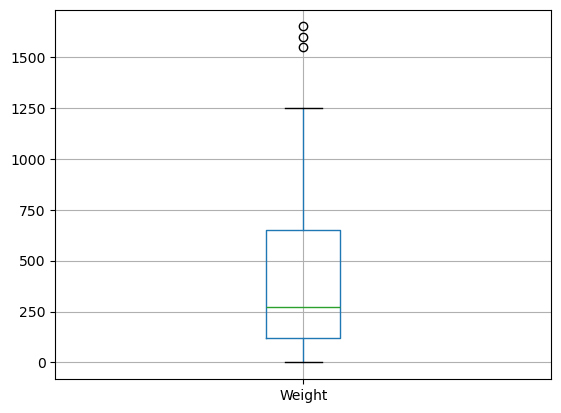

In [10]:
df.boxplot(column=['Weight'])
plt.show()

The values flagged as outliers by the boxplot are still plausible observations, so we will keep them. A fish can weigh 1650 g, which is the maximum value of `Weight`.

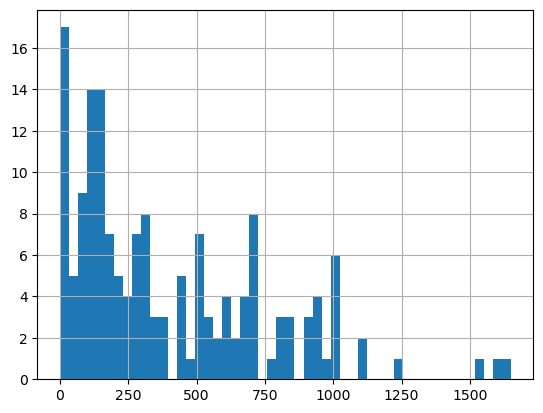

In [11]:
df['Weight'].hist(bins=50)
plt.show()

Depending on the regression model we train, we may want to apply a logarithmic transformation to the target variable. i.e. `Weight`.

## 2. Data Preparation

First, let's drop the data row with weight 0.

In [12]:
df = df.drop(df[df.Weight == 0].index)

Next we split the columns into a target *`y`* and predictors *`X`*.

In [13]:
y = df['Weight']
X = df.drop('Weight', axis=1)

Next, similar to the classification exercise, we will build a data preprocessing pipeline in which we will apply one-hot encoding to the `Species` column, as well as scalers to the numerical predictors as we discussed above. The transformation of the target will be done later when we build the final pipeline.

In [14]:
preprocess_pipeline = ColumnTransformer(
    transformers = [
        ("no_outliers", StandardScaler(), ['Height', 'Width']),
        ("categorical", OneHotEncoder(drop='first', sparse_output=False), ['Species'])
    ],
    remainder=RobustScaler() # i.e. ['Length1', 'Length2', 'Length3']
).set_output(transform="pandas") 

# The output of preprocess_pipeline is set to "pandas", 
# so we can view the output of the pipeline as a dataframe with 
# the names of the columns. We do this just as a test in the next few cells. 
# Otherwise, the output would be a numpy array.

Let’s fit the preprocessing pipeline on the predictors just to test if it does what we expect it to do. This is only to inspect the transformed output; actual model training below performs preprocessing inside cross-validation.

In [15]:
X_transformed = preprocess_pipeline.fit_transform(X);

In [16]:
X_transformed.head()

,no_outliers__Height,no_outliers__Width,categorical__Species_Parkki,categorical__Species_Perch,categorical__Species_Pike,categorical__Species_Roach,categorical__Species_Smelt,categorical__Species_Whitefish,remainder__Length1,remainder__Length2,remainder__Length3
0,0.591654,-0.240092,0.0,0.0,0.0,0.0,0.0,0.0,-0.154982,-0.135593,0.018209
1,0.815870,-0.070461,0.0,0.0,0.0,0.0,0.0,0.0,-0.095941,-0.074576,0.091047
2,0.792000,0.161475,0.0,0.0,0.0,0.0,0.0,0.0,-0.103321,-0.061017,0.084977
3,0.874260,0.018572,0.0,0.0,0.0,0.0,0.0,0.0,0.073801,0.108475,0.230653
4,0.807462,0.421564,0.0,0.0,0.0,0.0,0.0,0.0,0.088561,0.108475,0.261002


In [17]:
X_transformed.tail()

,no_outliers__Height,no_outliers__Width,categorical__Species_Parkki,categorical__Species_Perch,categorical__Species_Pike,categorical__Species_Roach,categorical__Species_Smelt,categorical__Species_Whitefish,remainder__Length1,remainder__Length2,remainder__Length3
154,-1.610713,-1.800030,0.0,0.0,0.0,0.0,1.0,0.0,-1.018450,-1.030508,-0.989378
155,-1.531396,-1.874035,0.0,0.0,0.0,0.0,1.0,0.0,-1.003690,-1.016949,-0.983308
156,-1.567130,-1.881876,0.0,0.0,0.0,0.0,1.0,0.0,-0.974170,-0.976271,-0.965099
157,-1.427976,-1.399948,0.0,0.0,0.0,0.0,1.0,0.0,-0.892989,-0.888136,-0.880121
158,-1.414103,-1.511610,0.0,0.0,0.0,0.0,1.0,0.0,-0.848708,-0.840678,-0.819423


Now, let's split the original dataset into training and test sets.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

## 3. Model Training

Now, let's train a couple of regressors by exploring various combinations of values of their hyperparameters.

Hyperparameters are tuned using 10-fold cross-validation on the training set. For each hyperparameter combination, the model is trained on 9 folds and validated on the remaining fold, repeated 10 times.

The reported cross-validation scores are the mean and standard deviation across folds.

In [19]:
# Prepare a 10-fold CV splitter (used for each regressor in this lab)
cv10 = KFold(n_splits=10, shuffle=True, random_state=42)

# Evaluate multiple metrics during cross-validation (CV).
# The best model will be selected based on mean CV R² score,
# while other metrics are reported for comparison.
# 
# For regression in scikit-learn, the scoring names are slightly tricky because 
# error metrics are returned as negative values (since GridSearchCV maximises scores). 
# So for MSE, RMSE and MAE you must use the neg_* versions.
scoring = {
    "neg_MSE": "neg_mean_squared_error",
    "neg_RMSE": "neg_root_mean_squared_error",
    "neg_MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

Next, we train `RandomForestRegressor` on the training set with a range of possible parameters in order to find the best parameters by cross-validation. To do this we will build another [main] pipeline which includes the preprocessing pipeline and `RandomForestRegressor`. We also add an element for dimensionality reduction after the preprocessing pipeline.

Here we will attempt three different dimensionality reduction methods and we will let the grid search pick the best one. These are:

- Principal Component Analysis (PCA)
- Recursive Feature Elimination (RFE) with estimator `svm.SVR`
- Recursive Feature Elimination (RFE) with estimator `LinearRegression`

Note that RFE is using regression algorithms for selecting the best features. These regression algorithms can be different from the regression algorithm at the end of the main pipeline.

The main pipeline will take care for separately preprocessing the training and validation sets after the training set is further split into training and validation sets in the process of cross-validation. It also applies the dimensionality reduction method separately to the training and validation sets.

### 3.1. Random Forest Pipeline

The pipeline contains a placeholder for the dimensionality reduction method. We will treat the method as a parameter and let the grid search pick the best of the three methods.

In [20]:
pipe = Pipeline(steps=[('preprocess', preprocess_pipeline), 
                       ('reduce_dim', 'passthrough'),
                       ('ttr', TransformedTargetRegressor(
                           regressor=RandomForestRegressor(n_estimators=10, random_state=42),
                           func=np.log1p, 
                           inverse_func=np.expm1)
                       )
                      ]
               )

We limit the parameter grid to a few options for the `max_depth` parameter of `RandomForestRegressor` and to three alternative values for the number of features left after dimensionality reduction. More parameters and values can be explored. Here we limit the options to make sure the grid search does not take too long to execute.

In [21]:
N_FEATURES_OPTIONS = [2, 6, 11]
MAX_DEPTH_OPTIONS = [2, 4, 6, 8]

param_grid = [
    {
        'reduce_dim': [PCA(iterated_power=7)],
        'reduce_dim__n_components': N_FEATURES_OPTIONS,
        'ttr__regressor__max_depth': MAX_DEPTH_OPTIONS
    },
    {
        'reduce_dim': [RFE(svm.SVR(kernel='linear', gamma='auto')),RFE(LinearRegression())],
        'reduce_dim__n_features_to_select': N_FEATURES_OPTIONS,
        'ttr__regressor__max_depth': MAX_DEPTH_OPTIONS
    }  
]

In [22]:
rf_search = GridSearchCV(
    pipe, 
    param_grid,
    scoring=scoring,
    n_jobs=-1,
    cv=cv10,
    refit="R2",
    return_train_score=False)
rf_search.fit(X_train, y_train)

print("Best CV score = %0.3f:" % rf_search.best_score_)
print("Best parameters: ", rf_search.best_params_)

# store the best params and best model for later use
RF_best_params = rf_search.best_params_
RF_best_model = rf_search.best_estimator_
RF_best_cv_r2 = rf_search.best_score_

Best CV score = 0.974:
Best parameters:  {'reduce_dim': PCA(iterated_power=7), 'reduce_dim__n_components': 2, 'ttr__regressor__max_depth': 8}


**Note:** `GridSearchCV` can evaluate several metrics at the same time. By setting **refit="R2"**, we tell it to select and refit (on the whole training set) the model that achieved the best mean cross-validation R², even though other metrics are also computed. This best model can then be accessed via the `.best_estimator_` attribute of the `GridSearchCV`.

Let's repeat the same experiment but with `LinearRegression` as the regression algorithm.

### 3.2. Linear Regression Pipeline

In [23]:
pipe = Pipeline(steps=[('preprocess', preprocess_pipeline), 
                       ('reduce_dim', 'passthrough'),
                       ('ttr', TransformedTargetRegressor(
                           regressor=LinearRegression(),
                           func=np.log1p, 
                           inverse_func=np.expm1)
                       )
                      ]
               )

Again, we limit the parameter grid to one parameter of `LinearRegression` and three alternative values for the number of features after dimensionality reduction to make sure the grid search does not take too long to execute (for the purpose of having a fast-to-execute example here).

In [24]:
N_FEATURES_OPTIONS = [2, 6, 11]
FIT_INTERCEPT_OPTIONS = [False, True]

param_grid = [
    {
        'reduce_dim': [PCA(iterated_power=7)],
        'reduce_dim__n_components': N_FEATURES_OPTIONS,
        'ttr__regressor__fit_intercept': FIT_INTERCEPT_OPTIONS
    },
    {
        'reduce_dim': [RFE(svm.SVR(kernel='linear', gamma='auto')),RFE(LinearRegression())],
        'reduce_dim__n_features_to_select': N_FEATURES_OPTIONS,
        'ttr__regressor__fit_intercept': FIT_INTERCEPT_OPTIONS
    }  
]

In [25]:
lr_search = GridSearchCV(
    pipe, 
    param_grid,
    scoring=scoring,    
    n_jobs=-1,
    cv=cv10,
    refit="R2",
    return_train_score=False)

lr_search.fit(X_train, y_train)
print("Best CV score = %0.3f:" % lr_search.best_score_)
print("Best parameters: ", lr_search.best_params_)

# store the best params and best model for later use
LR_best_params = lr_search.best_params_
LR_best_model = lr_search.best_estimator_
LR_best_cv_r2 = lr_search.best_score_

Best CV score = 0.774:
Best parameters:  {'reduce_dim': RFE(estimator=SVR(gamma='auto', kernel='linear')), 'reduce_dim__n_features_to_select': 11, 'ttr__regressor__fit_intercept': True}


We can now further compare the best models by evaluating them across several metrics using cross-validation on the training set.

## 4. Cross-Validated Model Comparison (Training Set Only)

We now compare the scores of the best Random Forest and Linear Regression models found by the grid search. The metrics we use are:

- mean squared error (MSE)
- root mean squared error (RMSE)
- mean absolute error (MAE)
- R²

to choose the better regressor for our problem.

### 4.1. Report Mean ± Standard Deviation of Several Metrics Across CV Folds

In [26]:
# Compute CV metrics (mean ± std) for the *best* Linear Regression and Random Forest models
models = {
    "Random Forest": RF_best_model,
    "Linear Regression": LR_best_model
}

cv_results = {}
negative_metrics = [k for k in scoring if k.startswith("neg_")]

for name, model in models.items():
    res = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv10,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    cv_results[name] = {m: res[f"test_{m}"] for m in scoring.keys()}

In [27]:
# Print a concise summary with non-negative error metrics
for name, metrics_dict in cv_results.items():
    print("\n" + name)
    for m, vals in metrics_dict.items():
        if m in negative_metrics:
            vals_to_report = -vals
            metric_name = m.replace("neg_", "")
        else:
            vals_to_report = vals
            metric_name = m
        print(f"  {metric_name:5s}: mean={np.mean(vals_to_report):.3f}, std={np.std(vals_to_report):.3f}")


Random Forest
  MSE  : mean=3563.715, std=3262.618
  RMSE : mean=53.479, std=26.527
  MAE  : mean=32.529, std=14.703
  R2   : mean=0.974, std=0.014

Linear Regression
  MSE  : mean=42094.560, std=93344.046
  RMSE : mean=134.459, std=154.969
  MAE  : mean=67.212, std=48.803
  R2   : mean=0.774, std=0.430


### 4.2. Visual Comparison of the Results Across CV Folds

In [28]:
# the names of the models
model_names = list(models.keys())

#### 4.2.1. Mean RMSE and MAE Compared

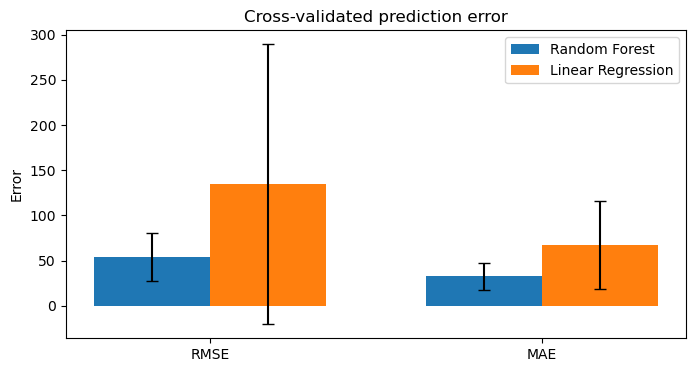

In [29]:
# Plot mean ± std for each metric
wanted_metrics = ["RMSE", "MAE"]
error_metrics = [m for m in scoring if m.replace("neg_", "") in wanted_metrics]
display_errors = [m.replace("neg_", "") for m in error_metrics]

x = np.arange(len(error_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8,4))

for i, name in enumerate(model_names):
    values = [-np.mean(cv_results[name][m]) for m in error_metrics]
    stds   = [np.std(cv_results[name][m]) for m in error_metrics]
    ax.bar(x + (i-0.5)*width, values, width, yerr=stds, capsize=4, label=name)

ax.set_xticks(x)
ax.set_xticklabels(display_errors)
ax.set_ylabel("Error")
ax.set_title("Cross-validated prediction error")
ax.legend()

plt.show()

**Note:** RMSE and MAE values cannot be negative; if an error bar extends below 0, this is only a visual artefact of plotting mean ± standard deviation symmetrically across cross-validation folds.

#### 4.2.2. Mean R² Values Compared

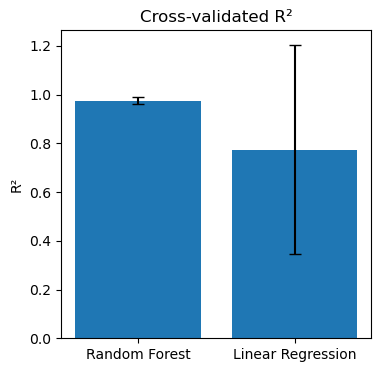

In [30]:
fig, ax = plt.subplots(figsize=(4,4))

means_r2 = [np.mean(cv_results[name]["R2"]) for name in model_names]
stds_r2  = [np.std(cv_results[name]["R2"]) for name in model_names]

ax.bar(model_names, means_r2, yerr=stds_r2, capsize=4)

ax.set_ylabel("R²")
ax.set_title("Cross-validated R²")

plt.show()

Error bars represent ±1 standard deviation of the metric across the 10 cross-validation folds.

#### 4.2.3. Distribution of Cross-Validation Results

The boxplots below show how RMSE, MAE, and R² vary across the 10 cross-validation folds, giving a clearer picture of the spread and stability of each model’s performance than mean values alone.

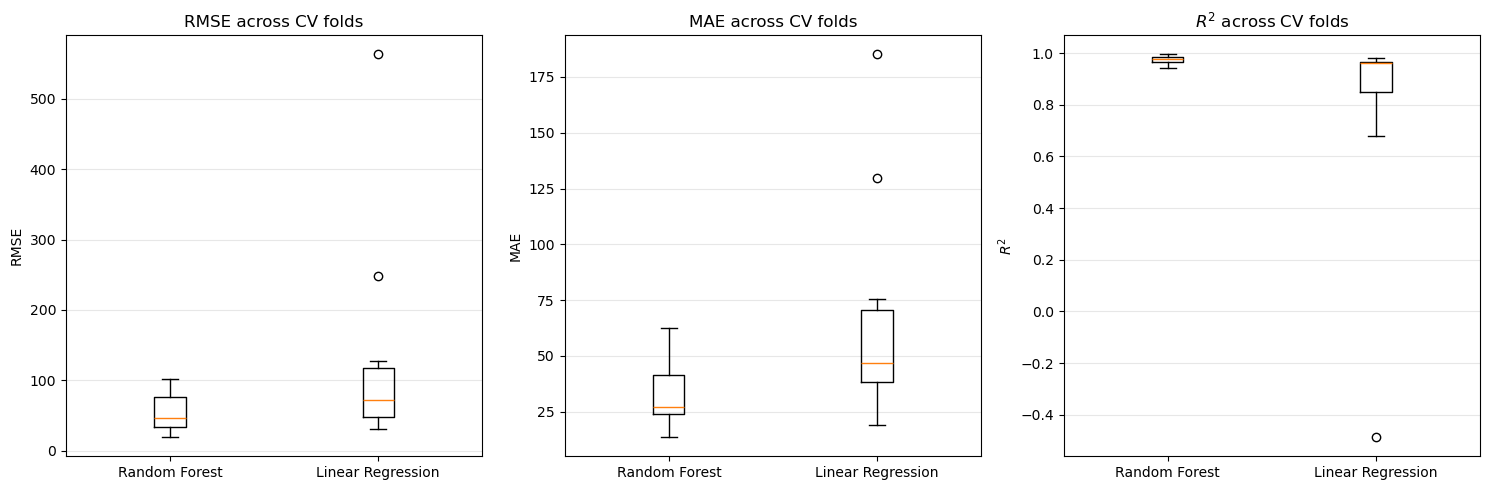

In [31]:
rmse_data = [-cv_results[name]["neg_RMSE"] for name in model_names]
mae_data  = [-cv_results[name]["neg_MAE"] for name in model_names]
r2_data   = [cv_results[name]["R2"] for name in model_names]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].boxplot(rmse_data, tick_labels=model_names)
axes[0].set_title("RMSE across CV folds")
axes[0].set_ylabel("RMSE")
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot(mae_data, tick_labels=model_names)
axes[1].set_title("MAE across CV folds")
axes[1].set_ylabel("MAE")
axes[1].grid(axis="y", alpha=0.3)

axes[2].boxplot(r2_data, tick_labels=model_names)
axes[2].set_title("$R^2$ across CV folds")
axes[2].set_ylabel("$R^2$")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 4.3. Final Model Selection

The model with the highest mean cross-validated R² score is selected. Note that the selected model is trained on the full training set (using the optimal hyperparameters).

In [32]:
# Choose the best regressor based on cross-validated R² score on the training set
if RF_best_cv_r2 >= LR_best_cv_r2:
    best_name = "Random Forest"
    best_model = RF_best_model
    best_cv_r2 = RF_best_cv_r2
else:
    best_name = "Linear Regression"
    best_model = LR_best_model
    best_cv_r2 = LR_best_cv_r2

print(f"Chosen model based on 10-fold CV R² on the training set: {best_name} (mean CV R² = {best_cv_r2:.3f})")

Chosen model based on 10-fold CV R² on the training set: Random Forest (mean CV R² = 0.974)


## 5. Final Evaluation on the Test Set

Now we can evaluate the selected best model on the held-out test dataset and report its performance (MSE, RMSE, MAE, R², etc.).

Important: the test set is used only once for final evaluation. Model selection (e.g., choosing between Random Forest vs Linear Regression and tuning hyperparameters) is done using cross-validation on the training data.

In [33]:
# predicted values
y_pred = best_model.predict(X_test)

# metrics
metrics = {
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
    "MAE": mean_absolute_error(y_test, y_pred),
    "R2": r2_score(y_test, y_pred)
}

print("\nTest set performance")
for m, val in metrics.items():
    print(f"  {m:5s}: {val:.3f}")


Test set performance
  MSE  : 2433.821
  RMSE : 49.334
  MAE  : 33.712
  R2   : 0.982


We can also examine a scatter plot of the predicted versus actual values of the target variable in the test set. If the model is good, points should lie close to the diagonal.

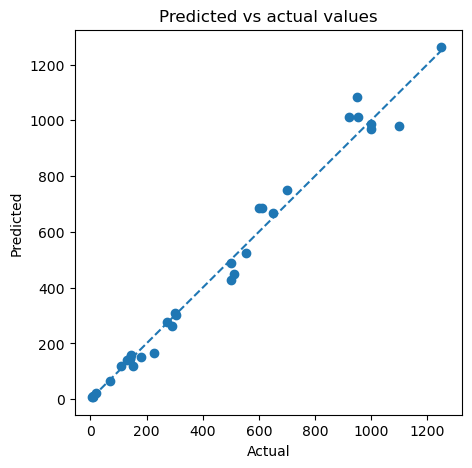

In [34]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs actual values")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.show()

## 6. Export the Final Model

We can also save this model to disk.

In [35]:
filename = 'best_regression_model.sav'
pickle.dump(best_model, open(filename, 'wb'))